In [2]:
# 📩 SMS Spam Detection using Machine Learning

## Introduction

This project uses Machine Learning to classify SMS messages as either:

- **Ham (Human)** — normal, legitimate messages
- **Spam** — unwanted or suspicious messages

The model uses **TF-IDF Vectorization** to convert text messages into numerical features and **Logistic Regression** for classification.

### Objective

The objective of this project is to build a machine learning model that can automatically detect whether a given SMS message is spam or human.

SyntaxError: invalid character '—' (U+2014) (3575312695.py, line 7)

In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'sms+spam+collection (1)',
 'SMS_Spam_Detection.ipynb',
 'sms_spam_model.pkl',
 'tfidf_vectorizer.pkl']

In [4]:
import pandas as pd

file_path = "sms+spam+collection (1)/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep='\t',#tell that the 2 columes are seprated by a tab
    header=None,
    names=['label','message'] #label= ham or spam, message= the actual SMS
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:

df.shape, #(number of rows,number of columes)

#5572 row = SMS message, 2 columns = label and message



((5572, 2),)

In [6]:
df["label"].value_counts(),#tells how many ham and spam msg we have
#there are more normal data then spam data this is called class imbalance

(label
 ham     4825
 spam     747
 Name: count, dtype: int64,)

In [7]:

df.info(), #checks what type of data you have

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


(None,)

In [8]:



df.isnull().sum(), #check are there missing values


(label      0
 message    0
 dtype: int64,)

In [9]:
df.duplicated().sum(), #are there duplicate SMS messages

#its output tells us there is 403 duplicate rows in the data set
#duplictes are not good because it can give the particular example more weight than other message
#there can be 2 types of duplicated data 
#1 Accidently Duplecated
#2 Genuine Repated msg
# Duplicates = bad -> delete all (no its wrong) = inspect the duplicate data and undersand the dataset first df.head

(np.int64(403),)

In [10]:
df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [11]:
df.tail(10)

,label,message
5562,ham,Ok lor... Sony ericsson salesman... I ask shuh...
5563,ham,Ard 6 like dat lor.
5564,ham,Why don't you wait 'til at least wednesday to ...
5565,ham,Huh y lei...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [12]:
df.sample(10,random_state=42)

,label,message
3245,ham,Squeeeeeze!! This is christmas hug.. If u lik ...
944,ham,And also I've sorta blown him off a couple tim...
1044,ham,Mmm thats better now i got a roast down me! i...
2484,ham,Mm have some kanji dont eat anything heavy ok
812,ham,So there's a ring that comes with the guys cos...
2973,ham,Sary just need Tim in the bollox &it hurt him ...
2991,ham,"Love isn't a decision, it's a feeling. If we c..."
2942,ham,My supervisor find 4 me one lor i thk his stud...
230,ham,Dear good morning now only i am up
1181,ham,I'm in chennai velachery:)


In [13]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [14]:
df['label'].unique()

#we are running the last 2 codes because ML model can't learn from missing msg, missing label, unexpected categories such as "Spam","SPAM","unknown",etc

array(['ham', 'spam'], dtype=object)

In [15]:
df_clean = df.drop_duplicates()

print("Original Row:",len(df))
print("Rows after removing duplicates:",len(df_clean))
print("Duplicates removed:",len(df)-len(df_clean))

#instad of using df= df.drop_duplicates() we have used df_clean because we keep the original dataset available if we need to compair somthing later

Original Row: 5572
Rows after removing duplicates: 5169
Duplicates removed: 403


In [16]:
#check ham vs spam after cleaning

df_clean['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [17]:
df_clean['label'].value_counts(normalize=True)*100

#tells the % of each 
#normalize=True is used when we want %/proportion insted of the actual counts1

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

In [18]:
# df_clean['message_length'] = df_clean['message'].str.len()

In [19]:
df_clean=df.drop_duplicates().copy()

df_clean['message_length']=df_clean['message'].str.len()
#this means for every msg count how many characters are there in the msg
#doing this we are trying to find out spam mag tend to be longer on average. But we will not assume that we let the data tell us

In [20]:
df_clean[['message','message_length']].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
df_clean.groupby('label')['message_length'].mean()

label
ham      70.905890
spam    137.704441
Name: message_length, dtype: float64

In [22]:
import matplotlib.pyplot as plt



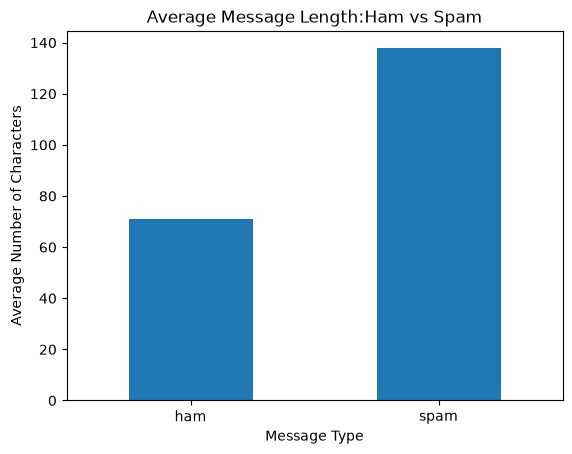

In [23]:
df_clean.groupby('label')['message_length'].mean().plot(kind='bar')

plt.title('Average Message Length:Ham vs Spam')
plt.xlabel('Message Type')
plt.ylabel('Average Number of Characters')
plt.xticks(rotation=0)
plt.show()

In [24]:
df_clean['label_num']=df_clean['label'].map({'ham':0,'spam':1})

In [25]:
df_clean[['label','label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [26]:
#Split our dataset (Train-TestSplit)

from sklearn.model_selection import train_test_split

X = df_clean['message']
Y = df_clean['label_num']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# x -> the SMS Msg our input
# Y -> whether each SMS is ham (0) or spam(1) (our answer/target)
#test_size = 0.2-> 20% testing, 80% training
#random_state=42 -> keep the same split every time we run it 
#stratify =Y -> keep the ham/spam proportaion similar in both sets  

In [27]:
print("Training messange:",len(X_train))
print("Testing messange:",len(X_test))

Training messange: 4135
Testing messange: 1034


In [28]:
#TF-IDF = text -> numbers

# TF-IDF = Term Frequency * Invers Document Frequency

# TF = Hoe offten does a word appear in this particular msg(word which appear multipal times in a messagr it has high TF)
# IDF = How rare is the word across all msg


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# from sklearn.feature_extraction.text import TfidfVectorizer
# ---> think of TfidfVectorizer as a tool that can do this =  SMS text -> numbers

# tfidf = TfidfVectorizer()
# ---> creates an actual object we were going to use

# X_train_tfidf = tfidf.fit_transform(X_train)
# ---> there are actually 2 operation happening here
# 1) fit = The Vectorizer lookes at the traininf msg and learn the vocabulary and also calculates the information it needs to assign TF_IDF value
# 2) transform = Then it covers every training SMS into numberical verctor
# X_train -> TF-IDF -> X_train_tfidf

# X_test_tfidf = tfidf.transform(X_test)
# ---> notice there is no fit beacuse we don't allow the testing data to teach the vectorizer anything 
# its has already learned everythong from the training data
# this helps in preventing data leakage
# X_test -> same TF-IDF -> X_test_tfidf


#  TF-IDF is a bridge between our text data and the ML model

In [30]:
print("Training Shape:",X_train_tfidf.shape)
print("Testing Shape:",X_test_tfidf.shape)

# OUTPUT
#  A shape is: (row,columns)

# 4135 row -> training sms msg
# 7680 columns -> different words/fetures discovered by TF_IDF

# 4135*7680 numerical feature matrix

# 7680 is same in in both because we learn the vocabulary from X_train and then use the same vocublary to test the same

Training Shape: (4135, 7680)
Testing Shape: (1034, 7680)


In [31]:
feature_names = tfidf.get_feature_names_out()

print("Total features:",len(feature_names))
print(feature_names[:50])

Total features: 7680
['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '03' '04' '0430'
 '05' '050703' '0578' '06' '07' '07090201529' '07090298926' '0721072'
 '07732584351' '07734396839' '07742676969' '07753741225' '0776xxxxxxx'
 '07781482378' '077xxx' '078' '07808' '07808247860' '07808726822'
 '07815296484' '078498' '07880867867' '0789xxxxxxx' '07946746291'
 '0796xxxxxx' '07xxxxxxxxx' '08' '0800' '08000407165' '08000776320'
 '08000839402' '08000930705' '08000938767' '08001950382' '08002888812']


In [32]:
#TEAIN OUR FIRST ML MODEL
# Logistic Regression => in sklearn is a classification algorithm 

# X_teain_tfidf ->information from sms msg
# Y_train -> correct answers(0=ham,1=spam)

from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression(class_weight="balanced")

In [47]:
model.fit(X_train_tfidf,Y_train)

# fit means learn from the training data

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [48]:
print("Model training completed!")

Model training completed!


In [49]:
Y_pred = model.predict(X_test_tfidf)
Y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(1034,))

In [50]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test,Y_pred)
print("Model Accuracy:",accuracy)

# y_test = the correct ans from the test msg
# y_pred = the ans prediction by a model 

Model Accuracy: 0.9738878143133463


In [51]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,Y_pred)
print(cm)

[[887  16]
 [ 11 120]]


In [52]:
# 899 = ham correctly predicted as ham 
# 4= ham incorrect prediction
# 33 = spam incorrect prediction 
# 98 = spam correct prediction

In [53]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       903
           1       0.88      0.92      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.95      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [54]:
# tell how the model is performing

# precision = when the mordel says sapm, how offern its actually spam
# recall = off all the actual spam msg how many did the model successfully find
# f1-score = combines precision and recall into one number
# support = how many eg were there in the test data 

In [55]:
message = input("Enter your msg:")
message_tfidf=tfidf.transform([message])
prediction = model.predict(message_tfidf)

if prediction[0]==1:
    print("SPAM ☠️")
else:
    print("HUMAN 👤")

Enter your msg: You won a car!


HUMAN 👤


In [42]:
import pickle

# Save the trained model

with open("sms_spam_model.pkl","wb")as file:
    pickle.dump(model,file)

    # pickle.dump(model,file) to save the trained model's learned parameters into sms_spam_model.pkl , thing of it like saving your trained brain

# Save the TF-IDF vectorizer

with open("tfidf_vectorizer.pkl","wb")as file:
    pickle.dump(tfidf,file)

print("Model and TF-IDF Vectorizer saved successfully")

Model and TF-IDF Vectorizer saved successfully


In [43]:
import pickle

# Load the saved model

with open("sms_spam_model.pkl","rb")as file:
    loaded_model = pickle.load(file)

# Load the saved TF-IDF vectorizer 

with open("tfidf_vectorizer.pkl","rb")as file:
    loaded_tfidf = pickle.load(file)

print("Model and Vectorizer loded successfully!")

Model and Vectorizer loded successfully!
